# PHASE-1 · Diagnostic — Confirm OAI vs NHANES — Shared Severity Axis?

A read-only diagnostic that determines whether the external Mendeley gap arises
from a labeling difference (recoverable by re-fitting grade boundaries) or from a
genuine image-feature difference (irreducible). The trained maximum-model
checkpoint is used to project each dataset's images onto a one-dimensional latent
severity axis; the test is whether the datasets occupy the same axis with shifted
grade cut-points, or genuinely separate regions of feature space.

This notebook only reads existing checkpoints and the shared image array. All
outputs are written to a separate folder (scope3_diag); no existing file is
modified.

## Setup (read-only on existing data and checkpoints)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys, importlib
sys.path.insert(0,'/content/drive/MyDrive/Master Thesis/scope3')
import config; importlib.reload(config)
import numpy as np, pandas as pd, json, glob
from pathlib import Path
import torch, torch.nn.functional as F
if 'training_lib_max' in sys.modules: importlib.reload(sys.modules['training_lib_max'])
import training_lib_max as TM
device='cuda' if torch.cuda.is_available() else 'cpu'

PROJECT_ROOT = Path('/content/drive/MyDrive/Master Thesis')
DIAG_DIR = PROJECT_ROOT/'scope3_diag'
DIAG_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Diagnostic outputs ->', DIAG_DIR)
manifest = TM.prepare_local_data()
print(f'Manifest: {len(manifest):,} rows (read-only)')

Mounted at /content/drive
Device: cuda
Diagnostic outputs -> /content/drive/MyDrive/Master Thesis/scope3_diag
Copied array in 33s
Loaded array (61558, 224, 224) in 1s
Manifest: 61,558 rows (read-only)


## Load the trained maximum model (read-only)

The OAI-fold maximum checkpoint is used as the feature extractor. It was trained
without seeing OAI or Mendeley as test data in the same run, so its features are a
fair severity representation for this diagnostic.

In [2]:

cands = ['max_oai_seed0_best.pt','max_mrkr_seed0_best.pt','max_nhanes3_seed0_best.pt','max_mendeley_seed0_best.pt']
ckpt = None
for c in cands:
    p = TM.MAX_CKPT_DIR/c
    if p.exists(): ckpt=p; break
if ckpt is None:
    found = glob.glob(str(TM.MAX_CKPT_DIR/'*_best.pt'))
    ckpt = Path(found[0]) if found else None
if ckpt is None: raise FileNotFoundError('No MAX checkpoint found in scope3_max/checkpoints')
print('Feature extractor:', ckpt.name)

model = TM.OrdinalNet(config.NUM_CLASSES, 4, use_hierarchical=True).to(device)
TM.load_ckpt(str(ckpt), model, None); model.eval()
print('Model loaded (read-only).')

Feature extractor: max_oai_seed0_best.pt
Downloading: "https://download.pytorch.org/models/convnext_large-ea097f82.pth" to /root/.cache/torch/hub/checkpoints/convnext_large-ea097f82.pth


100%|██████████| 755M/755M [00:04<00:00, 175MB/s]


Model loaded (read-only).


## Extract penultimate features for OAI and NHANES

A bounded random sample from each dataset is passed through the backbone to obtain
feature vectors. These are reduced to a single severity dimension.

In [3]:
import cv2
@torch.no_grad()
def extract_features(df, n=1200, bs=16):
    df = df.sample(min(n,len(df)), random_state=0).reset_index(drop=True)
    feats=[]; ys=[]
    for s in range(0,len(df),bs):
        sub=df.iloc[s:s+bs]; xb=[]
        for _,r in sub.iterrows():
            a=TM._resize(TM.joint_crop(TM._get_image(r)))
            a=a.astype(np.float32)/255.0; a=(a-0.485)/0.229
            xb.append(torch.from_numpy(a).unsqueeze(0).repeat(3,1,1))
        f=model.backbone(torch.stack(xb).to(device))
        if f.dim()==4: f=f.mean(dim=[-2,-1])
        feats.append(f.cpu().numpy()); ys.extend(sub['kl_grade'].tolist())
    return np.vstack(feats), np.array(ys)

f_oai,  y_oai  = extract_features(manifest[manifest['dataset']=='oai'])
f_mend, y_mend = extract_features(manifest[manifest['dataset']=='nhanes3'])
print(f'OAI features:      {f_oai.shape}')
print(f'Mendeley features: {f_mend.shape}')

OAI features:      (1200, 1536)
Mendeley features: (1200, 1536)


## The decisive test: do both datasets share the severity axis?

A severity direction is learned on OAI (the direction in feature space along which
KL grade increases). Both datasets are projected onto it. Two questions follow.
First: does the same direction order Mendeley's grades correctly (does severity
increase with KL on Mendeley too)? Second: do the two datasets overlap on this
axis, or sit in separate regions? If the axis orders both and they overlap, the gap
is a boundary/labeling difference. If Mendeley is not ordered or sits apart, the gap
is in the features.

In [4]:
from sklearn.linear_model import LogisticRegression
from scipy.stats import spearmanr

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(f_oai, y_oai)
s_oai  = lda.transform(f_oai).ravel()
s_mend = lda.transform(f_mend).ravel()

if spearmanr(s_oai, y_oai).correlation < 0:
    s_oai, s_mend = -s_oai, -s_mend

rho_oai  = spearmanr(s_oai,  y_oai ).correlation
rho_mend = spearmanr(s_mend, y_mend).correlation

m_o, sd_o = s_oai.mean(), s_oai.std()+1e-8
z_oai  = (s_oai  - m_o)/sd_o
z_mend = (s_mend - m_o)/sd_o
shift  = z_mend.mean() - z_oai.mean()
overlap = float(((z_mend>np.percentile(z_oai,5))&(z_mend<np.percentile(z_oai,95))).mean())

print('=== DIAGNOSTIC RESULT ===')
print(f'Severity axis orders OAI grades      : rho = {rho_oai:.3f}  (sanity check, should be high)')
print(f'Same axis orders NHANES grades     : rho = {rho_mend:.3f}  <-- KEY')
print(f'NHANES distribution shift from OAI : {shift:+.2f} std units')
print(f'NHANES falls within OAI range      : {overlap:.1%}')
print()
if rho_mend > 0.45 and overlap > 0.4:
    verdict='SHARED AXIS — gap is LABELING. Re-fitting grade boundaries may recover NHANES. The novel method is alive.'
elif rho_mend > 0.45 and overlap <= 0.4:
    verdict='AXIS ORDERS MENDELEY but it sits apart — partial: severity is readable, but a feature shift remains. Boundary re-fit may partially help.'
else:
    verdict='DIFFERENT AXES — the severity axis does NOT order NHANES. The gap is in the IMAGES, not the labels. Definitive finding: the structural gap is feature-level.'
print('VERDICT:', verdict)

json.dump({'rho_oai':float(rho_oai),'rho_mend':float(rho_mend),'shift':float(shift),
           'overlap':float(overlap),'verdict':verdict},
          open(str(DIAG_DIR/'phase1_diag_oai_vs_nhanes3.json'),'w'), indent=2)
print('\nSaved: scope3_diag/phase1_diag_oai_vs_nhanes3.json')

=== DIAGNOSTIC RESULT ===
Severity axis orders OAI grades      : rho = 0.754  (sanity check, should be high)
Same axis orders NHANES grades     : rho = 0.101  <-- KEY
NHANES distribution shift from OAI : +1.41 std units
NHANES falls within OAI range      : 29.8%

VERDICT: DIFFERENT AXES — the severity axis does NOT order NHANES. The gap is in the IMAGES, not the labels. Definitive finding: the structural gap is feature-level.

Saved: scope3_diag/phase1_diag_oai_vs_nhanes3.json


## Visualization: severity distributions per grade

If both datasets share the axis, their per-grade severity distributions overlap and
increase monotonically. If Mendeley sits apart or its grades do not separate along
the axis, the gap is feature-level.

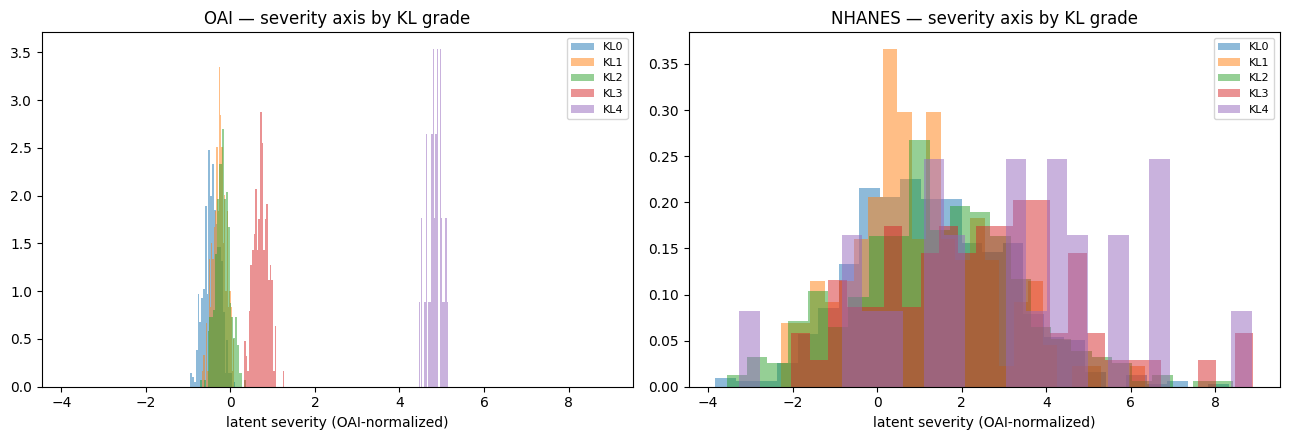

Saved: scope3_diag/phase1_sev_oai_vs_nhanes3.png

Read the verdict above. If SHARED AXIS -> build the full latent-severity method (Phase 2).
If DIFFERENT AXES -> you have proven the Mendeley gap is feature-level (a definitive result).


In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(13,4.5), sharex=True)
for ax, s, y, name in [(axes[0], z_oai, y_oai, 'OAI'), (axes[1], z_mend, y_mend, 'NHANES')]:
    for kl in range(5):
        v = s[y==kl]
        if len(v)>3: ax.hist(v, bins=25, alpha=0.5, label=f'KL{kl}', density=True)
    ax.set_title(f'{name} — severity axis by KL grade'); ax.set_xlabel('latent severity (OAI-normalized)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(str(DIAG_DIR/'phase1_sev_oai_vs_nhanes3.png'), dpi=140, bbox_inches='tight'); plt.show()
print('Saved: scope3_diag/phase1_sev_oai_vs_nhanes3.png')
print('\nRead the verdict above. If SHARED AXIS -> build the full latent-severity method (Phase 2).')
print('If DIFFERENT AXES -> you have proven the Mendeley gap is feature-level (a definitive result).')